<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-11 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> Generative Adversarial Networks </21> </html>


### Demonstration how to generate images of handwritten digits (like MNIST dataset) using
### a Deep Convolutional Generative Adversarial Network (DCGAN)

[source](https://arxiv.org/pdf/1511.06434.pdf)

![sample output](https://tensorflow.org/images/gan/dcgan.gif)

##### (GANs) can be described as models which are trained simultaneously by an adversarial process.

- A *generator* learns to create images that look real, while a *discriminator* learns to tell real images apart from fakes.
During training, the *generator* progressively becomes better at creating images that look real, while the *discriminator becomes better at telling them apart. The process reaches equilibrium when the *discriminator* can no longer distinguish real images from fakes.


_____________________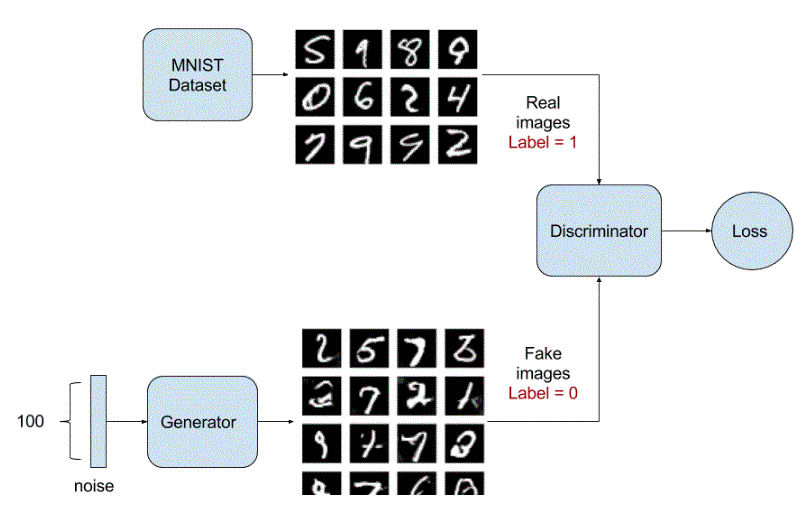

##### This notebook uses on the MNIST dataset. The following animation shows a series of images produced by the *generator* as it was trained for 50 epochs. The images begin as random noise, and increasingly resemble hand written digits over time.


### Import

In [ ]:
import tensorflow as tf

In [ ]:
tf.__version__

In [ ]:
# To generate GIF-images
# Imageio is a Python library that provides an easy interface to read and write a wide range of image data,
# including animated images, volumetric data, and scientific formats

!pip install imageio

In [ ]:
pip install git+https://github.com/tensorflow/docs

In [ ]:
import glob   # file operations
import imageio

import matplotlib.pyplot as plt

import numpy as np
import os     # file operations
import PIL    # Python Imaging Library

from tensorflow.keras import layers

import time

from IPython import display

### MNIST Dataset
After training, the generator will generate handwritten digits resembling the MNIST data.


In [ ]:
# Download data using internal Keras methods (in particular, mnist.load_data ())
# This is implemented by Keras for popular datasets

(train_images, train_labels), (_, _) = tf.keras.datasets.mnist.load_data()

# (_, _) -for test part which is not needed for GAN


In [ ]:
# look at some examples of the training data

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(train_images[i], cmap='gray', interpolation='none')
    plt.title("Class {}".format(train_labels[i]))

In [ ]:
train_images.shape

In [ ]:
# Normalisation

train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5 # Normalise the images to [-1, 1]

In [ ]:
train_images.shape

In [ ]:
BUFFER_SIZE = 60000
BATCH_SIZE = 256

In [ ]:
#tf.data.Dataset.from_tensor_slices?

In [ ]:
# Batch and shuffle the data

train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
train_dataset

### The Generator

- The generator uses `tf.keras.layers.Conv2DTranspose` (upsampling) layers to produce an image from a seed (random noise). Start with a `Dense` layer that takes this seed as input, then upsample several times until you reach the desired image size of 28x28x1. Notice the `tf.keras.layers.LeakyReLU` activation for each layer, except the output layer, which uses tanh.


In [ ]:
def make_generator_model():

    model = tf.keras.Sequential()        # neural network, where the layers go one after another

# Dense - type of neural network layer, all neurons of the previous level are connected to each neuron of the subsequent
    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))

# BatchNormalization - type of normalisation; look at https://keras.io/layers/normalization/
    model.add(layers.BatchNormalization())

# Leaky version of a Rectified Linear Unit; look at https://www.tensorflow.org/api_docs/python/tf/keras/layers/LeakyReLU
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256) # Note: None is the batch size

# Conv2DTranspose - Transposed convolution layer (sometimes called Deconvolution);
# look at https://keras.io/layers/convolutional/
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    assert model.output_shape == (None, 7, 7, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 14, 14, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 28, 28, 1)

    return model

Use the generator to create an image.


In [ ]:
generator = make_generator_model()

noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)

plt.imshow(generated_image[0, :, :, 0], cmap='gray')

In [ ]:
#generator?

In [ ]:
# Describe why the image does not have a structure?

### The Discriminator

- The discriminator is a CNN-based image classifier.


In [ ]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                                     input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())

# Dropout consists in randomly setting a fraction rate of input units to 0 at each update during training time,
# which helps prevent overfitting; Look at https://keras.io/layers/core/

    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

- Use the (as yet untrained) discriminator to classify the generated images as real or fake. The model will be trained to output positive values for real images and negative values for fake images.


In [ ]:
discriminator = make_discriminator_model()
decision = discriminator(generated_image)
print(decision)

In [ ]:
#discriminator?

## Define the loss and optimisers

Define loss functions and optimisers for both models.


In [ ]:
# This method returns a helper function to compute cross entropy loss
# More information about cross entropy loss is here  
# https://ai.stackexchange.com/questions/3488/understanding-gan-loss-function

cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

### Discriminator loss

- This method quantifies how well the discriminator is able to distinguish real images from fakes. It compares the discriminator's predictions on real images to an array of 1s, and the discriminator's predictions on fake (generated) images to an array of 0s.


In [ ]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

### Generator loss
- The generator's loss quantifies how well it was able to trick the discriminator. Intuitively, if the generator is performing well, the discriminator will classify the fake images as real (or 1). Here, we will compare the discriminators decisions on the generated images to an array of 1s.


In [ ]:
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

- The discriminator and the generator optimizers are different since we will train two networks separately.


In [ ]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [ ]:
#tf.keras.optimizers.Adam?

### Save checkpoints

- It is useful in case a long running training task is interrupted.



In [ ]:
#tf.train.Checkpoint?

In [ ]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

## Training loop



In [ ]:
EPOCHS = 50  # if you have a power GPU or use Google Colab, you can take EPOCHS = 60 or more

noise_dim = 100
num_examples_to_generate = 16

In [ ]:
#tf.random.normal?

In [ ]:
# visualisation of the progress in the animated GIF)

seed = tf.random.normal([num_examples_to_generate, noise_dim])

In [ ]:
# Google Colaboration only !!

#EPOCHS = 100
EPOCHS = 70

- The training loop begins with generator receiving a random seed as input. That seed is used to produce an image. The discriminator is then used to classify real images (drawn from the training set) and fakes images (produced by the generator). The loss is calculated for each of these models, and the gradients are used to update the generator and discriminator.


In [ ]:
# tf.function causes the function to be "compiled".

@tf.function

def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      generated_images = generator(noise, training=True)

      real_output = discriminator(images, training=True)
      fake_output = discriminator(generated_images, training=True)

      gen_loss = generator_loss(fake_output)
      disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

In [ ]:
def train(dataset, epochs):
  for epoch in range(epochs):
    start = time.time()

    for image_batch in dataset:
      train_step(image_batch)

    # Produce images for the GIF as we go
    display.clear_output(wait=True)
    generate_and_save_images(generator,
                             epoch + 1,
                             seed)

    # Save the model every 15 epochs
    if (epoch + 1) % 15 == 0:
      checkpoint.save(file_prefix = checkpoint_prefix)

    print ('Time for epoch {} is {} sec'.format(epoch + 1, time.time()-start))

  # Generate after the final epoch
  display.clear_output(wait=True)
  generate_and_save_images(generator,
                           epochs,
                           seed)

**Generate and save images**



In [ ]:
def generate_and_save_images(model, epoch, test_input):
  # Notice `training` is set to False.
  # This is so all layers run in inference mode (batchnorm).

  predictions = model(test_input, training=False)

  fig = plt.figure(figsize=(4,4))

  for i in range(predictions.shape[0]):
      plt.subplot(4, 4, i+1)
      plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
      plt.axis('off')

  plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
  plt.show()

## Train the model
train() - training the generator and discriminator simultaneously.
It's important that the generator and discriminator do not overpower each other (e.g., that they train at a similar rate).

At the beginning of the training, the generated images look like random noise. As training progresses, the generated digits will look increasingly real. After about 50 epochs, they resemble MNIST digits.


In [ ]:
train(train_dataset, EPOCHS)

Restore the latest checkpoint.


In [ ]:
#checkpoint.restore?

In [ ]:
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

### Show the result as a GIF-file


In [ ]:
# Display a single image using the epoch number

def display_image(epoch_no):
  return PIL.Image.open('image_at_epoch_{:04d}.png'.format(epoch_no))

In [ ]:
display_image(EPOCHS)

Use `imageio` to create an animated gif using the images saved during training.


In [ ]:
anim_file = 'dcgan.gif'

with imageio.get_writer(anim_file, mode='I') as writer:
  filenames = glob.glob('image*.png')
  filenames = sorted(filenames)
  for filename in filenames:
    image = imageio.imread(filename)
    writer.append_data(image)
  image = imageio.imread(filename)
  writer.append_data(image)


In [ ]:
import tensorflow_docs.vis.embed as embed
embed.embed_file(anim_file)

If you're working in Colab, you can download the animation with the code below:


In [ ]:
# Google Colaboration only
try:
  from google.colab import files
except ImportError:
   pass
else:
  files.download(anim_file)

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

### You must copy a screenshot of the GAN training result at a specific epoch to your logbook. The screenshot must contain the digital images, the epoch number and the time spent training for this epoch.

### Determine this epoch number using the following method:

#### Take the last two digits from your SID.
#### If this number is less than or equal to 50, it is the required epoch number.
#### If it exceeds 50, divide it by 2 and round up if necessary.
#### For example, if your SID is 2187467, and the last two digits are 67, which is greater than 50.
#### Divide by 2, resulting in 33.5. Round up to 34, and this becomes your epoch number.

<html> <h4 style="font-style:bold; color:red;"> NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB OR ONEDRIVE. </h4> </html>

source:
[Introducing TF-GAN: A lightweight GAN library for TensorFlow 2.0](https://medium.com/tensorflow/introducing-tf-gan-a-lightweight-gan-library-for-tensorflow-2-0-36d767e1abae)